# 1. EDA

In [4]:
# Importation des bibliothèques et première lecture du dataset
%pip install -r requirements.txt
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

transactions_df = pd.read_csv("data/transactions.csv")
products_df = pd.read_csv("data/products.csv")
locations_df = pd.read_csv("data/locations.csv")

display(transactions_df.head())
display(transactions_df.info())
display(transactions_df.describe())


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


,Transaction ID,Date,Location ID,SKU,Quantity,Value ($)
0,9c42d970-ad54-47af-a151-8ba6955cc539,2021-02-01,8,Alpha,2,199.98
1,3f8cdb5c-3cc6-4851-ab35-315e41374749,2021-02-01,1,Alpha,1,99.99
2,b797ce5d-484c-4227-bf8f-9128599439e1,2021-02-02,9,Gamma,1,39.99
3,af535905-a385-403d-9eeb-ce10a4749412,2021-02-02,9,Gamma,1,39.99
4,b2edee5d-a3d0-4968-a0f8-98af60f51085,2021-02-03,7,Gamma,1,39.99


<class 'pandas.DataFrame'>
RangeIndex: 7951 entries, 0 to 7950
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Transaction ID  7951 non-null   str    
 1   Date            7951 non-null   str    
 2   Location ID     7951 non-null   int64  
 3   SKU             7951 non-null   str    
 4   Quantity        7951 non-null   int64  
 5   Value ($)       7951 non-null   float64
dtypes: float64(1), int64(2), str(3)
memory usage: 372.8 KB


None

,Location ID,Quantity,Value ($)
count,7951.000000,7951.000000,7951.000000
mean,4.977236,1.017356,68.672005
std,3.097024,1.491511,151.122384
min,1.000000,-1.000000,-99.990000
25%,2.000000,1.000000,39.990000
50%,6.000000,1.000000,69.990000
75%,8.000000,1.000000,99.990000
max,10.000000,132.000000,13198.680000


In [5]:
# Vérifications des valeurs qui sont censées être contrôlées et limitées

display(transactions_df["Location ID"].unique())
display(transactions_df["SKU"].unique())
display(transactions_df["Quantity"].unique())

array([ 8,  1,  9,  7,  6,  3,  2,  4,  5, 10])

<StringArray>
['Alpha', 'Gamma', 'Beta']
Length: 3, dtype: str

array([  2,   1,  -1,   3, 132])

In [6]:
# Vérification que toutes les Transaction ID sont uniques

transactions_df["Transaction ID"].is_unique

True

In [7]:
# Investigation des cas de la Quantity de 132

transactions_df[transactions_df["Quantity"]==132]

,Transaction ID,Date,Location ID,SKU,Quantity,Value ($)
2900,3812b8b6-6267-4a79-a3a9-3a0fe7888d3a,2022-07-08,7,Alpha,132,13198.68


In [8]:
# Investigation des cas de la Quantity négative
print("Transactions à Quantity = -1")
display(transactions_df[transactions_df["Quantity"]==-1])

neg_transactions = transactions_df[transactions_df["Quantity"]==-1]
keys = neg_transactions.set_index(["Date", "Location ID", "SKU"]).index
print("Transactions à Quantity = -1 et transactions de même propriétés le même jour")
display(transactions_df[transactions_df.set_index(["Date", "Location ID", "SKU"]).index.isin(keys)])

Transactions à Quantity = -1


,Transaction ID,Date,Location ID,SKU,Quantity,Value ($)
30,5de8955c-1e4f-43d7-ac9e-4ed73e1a2fdf,2021-02-10,8,Alpha,-1,-99.99
40,4b05bbe3-951d-45df-ba6e-2f26ea552a81,2021-02-11,2,Gamma,-1,-39.99
42,d4f5a7a6-1351-4fc1-b43b-c46970689b0b,2021-02-11,2,Gamma,-1,-39.99
85,e7956d10-d058-41ad-a683-156e45971a04,2021-02-24,9,Gamma,-1,-39.99
161,4c42ac83-36f5-4131-8338-0bd3e4bcaf76,2021-03-14,9,Beta,-1,-79.99
...,...,...,...,...,...,...
7470,279cd6da-f22d-4c5e-a108-6e468c583320,2024-12-19,8,Beta,-1,-79.99
7557,172ba2a5-7021-4bd4-bd87-cdeb0f60687b,2024-12-30,1,Gamma,-1,-39.99
7587,256f9758-4da8-4418-aac0-3de6401b239c,2025-01-07,3,Gamma,-1,-39.99
7604,531e2825-47ed-4dff-86d9-9a166c0ecc0f,2025-01-12,9,Gamma,-1,-39.99


Transactions à Quantity = -1 et transactions de même propriétés le même jour


,Transaction ID,Date,Location ID,SKU,Quantity,Value ($)
28,58422865-8b1a-4f2f-b6a1-adf4afbec624,2021-02-10,8,Alpha,1,99.99
29,3c9d8cbc-b075-442f-8c1c-60086ca04af4,2021-02-10,8,Alpha,1,99.99
30,5de8955c-1e4f-43d7-ac9e-4ed73e1a2fdf,2021-02-10,8,Alpha,-1,-99.99
39,290aec8d-159f-40fc-8a3e-762b38d92422,2021-02-11,2,Gamma,1,39.99
40,4b05bbe3-951d-45df-ba6e-2f26ea552a81,2021-02-11,2,Gamma,-1,-39.99
...,...,...,...,...,...,...
7603,e395e8f2-76fa-4737-8f96-8a61be1461c1,2025-01-12,9,Gamma,1,39.99
7604,531e2825-47ed-4dff-86d9-9a166c0ecc0f,2025-01-12,9,Gamma,-1,-39.99
7636,8992f2d9-d212-4f00-86b8-c0807652796a,2025-01-19,8,Alpha,-1,-99.99
7637,50f014e3-1c9a-44c8-8ae4-8701bfd31424,2025-01-19,8,Alpha,1,99.99


In [9]:
# Trouver les transactions correspondantes pour les transactions à quantity négative

# Séparer les -1 et les +1
neg_df = transactions_df[transactions_df["Quantity"] == -1].copy()
pos_df = transactions_df[transactions_df["Quantity"] == 1].copy()
pos_df["Value ($)"] = -pos_df["Value ($)"]

# Compter par groupe
neg_counts = (neg_df
              .groupby(["Date", "Location ID", "SKU", "Value ($)"])
              .agg(neg_count=("Transaction ID", "count"),
                   neg_ids=("Transaction ID", list))  # garder les IDs
             )

pos_counts = (pos_df
              .groupby(["Date", "Location ID", "SKU", "Value ($)"])
              .agg(pos_count=("Transaction ID", "count"),
                   pos_ids=("Transaction ID", list))
             )

# Joindre les deux
comparison = neg_counts.join(pos_counts, how="left")
comparison["pos_count"] = comparison["pos_count"].fillna(0)
comparison["pos_ids"] = comparison["pos_ids"].apply(lambda x: x if isinstance(x, list) else [])

# Cas problématiques : pas assez de +1 pour compenser les -1
problematic = comparison[comparison["pos_count"] < comparison["neg_count"]].copy()

# Extraire les Transaction ID sans correspondance
# (on retire les IDs qui ont un match, le reste est problématique)
def get_unmatched_ids(row):
    n_matched = int(row["pos_count"])
    return row["neg_ids"][n_matched:]
problematic["unmatched_ids"] = problematic.apply(get_unmatched_ids, axis=1)

print(f"{problematic['unmatched_ids'].apply(len).sum()} transactions à retirer")
problematic[["neg_count", "pos_count", "neg_ids", "pos_ids", "unmatched_ids"]]

29 transactions à retirer


neg_count  pos_count  \
Date       Location ID SKU   Value ($)                         
2021-03-14 9           Beta  -79.99             1        0.0   
2021-03-18 8           Gamma -39.99             1        0.0   
2021-03-29 8           Alpha -99.99             1        0.0   
           9           Gamma -39.99             1        0.0   
2021-03-31 2           Gamma -39.99             1        0.0   
2021-08-30 1           Beta  -79.99             1        0.0   
2021-09-10 2           Beta  -79.99             1        0.0   
2021-09-23 2           Beta  -79.99             1        0.0   
2021-10-27 1           Alpha -99.99             1        0.0   
2022-06-26 8           Alpha -99.99             1        0.0   
2022-11-17 9           Gamma -39.99             1        0.0   
2022-12-16 9           Gamma -39.99             1        0.0   
2022-12-26 2           Gamma -39.99             1        0.0   
2023-01-04 2           Gamma -39.99             1        0.0   
2023-01-07 2           Gamma -39.99             1        0.0   
2023-02-03 1           Beta  -79.99             1        0.0   
2023-02-15 8           Alpha -99.99             1        0.0   
2023-04-21 3           Gamma -39.99             1        0.0   
2023-04-27 2           Beta  -79.99             1        0.0   
2023-05-23 8           Gamma -39.99             1        0.0   
2023-05-28 3           Alpha -99.99             1        0.0   
2023-07-27 9           Gamma -29.99             1        0.0   
2023-11-28 3           Gamma -39.99             1        0.0   
2024-01-08 1           Gamma -39.99             1        0.0   
2024-01-10 9           Gamma -39.99             1        0.0   
2024-01-16 7           Beta  -69.99             1        0.0   
2024-07-08 7           Beta  -79.99             1        0.0   
2024-07-11 3           Alpha -99.99             1        0.0   
2025-01-07 3           Gamma -39.99             1        0.0   

                                                                       neg_ids  \
Date       Location ID SKU   Value ($)                                           
2021-03-14 9           Beta  -79.99     [4c42ac83-36f5-4131-8338-0bd3e4bcaf76]   
2021-03-18 8           Gamma -39.99     [d2f51a30-8724-453f-a360-78184fc2df97]   
2021-03-29 8           Alpha -99.99     [f6c8c594-18ac-47b4-83f2-a4c316aec9dd]   
           9           Gamma -39.99     [8193697c-a808-4fdd-8864-3d0d014e36e2]   
2021-03-31 2           Gamma -39.99     [825f3e78-dc57-4df6-b041-6f2ff51b997c]   
2021-08-30 1           Beta  -79.99     [b66fdf3d-c89a-4286-9158-7ecbffd5dd34]   
2021-09-10 2           Beta  -79.99     [9ac6b272-dfa5-45af-8747-ff962875d506]   
2021-09-23 2           Beta  -79.99     [14bc2fb9-697a-48ca-8117-44eeca8cc542]   
2021-10-27 1           Alpha -99.99     [54300dd7-9a41-42d2-b77f-04c9223142c3]   
2022-06-26 8           Alpha -99.99     [65cf89cb-814e-436c-b1ce-fea45cbb1867]   
2022-11-17 9           Gamma -39.99     [0326fc3e-4874-4f4d-814b-e6334c97d749]   
2022-12-16 9           Gamma -39.99     [4c78b230-4b84-40f9-859b-5a733e296753]   
2022-12-26 2           Gamma -39.99     [ca992d61-ca01-44e2-a5b2-1b3065cc420d]   
2023-01-04 2           Gamma -39.99     [051f64a7-81ca-4750-bbbf-d6c23846e516]   
2023-01-07 2           Gamma -39.99     [2839eecd-38c4-4800-a460-a9a7343a8d60]   
2023-02-03 1           Beta  -79.99     [cd927a3e-e0b8-48d6-89a5-f2aa8ef77375]   
2023-02-15 8           Alpha -99.99     [9e89f050-a953-4485-bcd8-2954e7c047c0]   
2023-04-21 3           Gamma -39.99     [6981c7a2-2865-43fe-ae5c-a7b544fa49b3]   
2023-04-27 2           Beta  -79.99     [9e4eb2ca-42bd-4033-81df-8a4c9b7e81c6]   
2023-05-23 8           Gamma -39.99     [aa4905c6-48e4-4d85-80c4-b23d2481254e]   
2023-05-28 3           Alpha -99.99     [d1b8c299-1a8b-4d19-9119-8e155abb3997]   
2023-07-27 9           Gamma -29.99     [bca2b872-e8fc-4de3-b61d-b6a7e6ab679e]   
2023-11-28 3           Gamma -39.99     [f92bdd68-bfd7-4b12-a591-f81e2ca2ef71]   
2024-

In [10]:
# Trouver les transactions antérieures les plus proches pour les transactions négatives qui n'ont pas de match

# Convertir avant le merge
transactions_df["Date"] = pd.to_datetime(transactions_df["Date"])
problematic_reset = problematic.reset_index()
problematic_reset["Date"] = pd.to_datetime(problematic_reset["Date"])

# Joindre avec les transactions originales pour avoir les Transaction ID
problematic_txns = transactions_df.merge(
    problematic_reset[["Date", "Location ID", "SKU", "Value ($)"]],
    on=["Date", "Location ID", "SKU", "Value ($)"],
    how="inner"
)

# Chercher la transaction correspondante (Quantity == 1) à la date la plus proche antérieure
left = problematic_txns.sort_values("Date")

right = (transactions_df[transactions_df["Quantity"] == 1][["Date", "Location ID", "SKU", "Transaction ID", "Value ($)"]]
         .rename(columns={
             "Date": "Date_matched",
             "Transaction ID": "Transaction ID_matched",
             "Value ($)": "Value ($)_matched"
         })
         .sort_values("Date_matched"))

problematic_corresponding_transactions = pd.merge_asof(
    left,
    right,
    left_on="Date",
    right_on="Date_matched",
    by=["Location ID", "SKU"],
    direction="backward"
)

problematic_corresponding_transactions[["Transaction ID", "Date", "Location ID", "SKU", "Value ($)",
            "Transaction ID_matched", "Date_matched", "Value ($)_matched"]]

,Transaction ID,Date,Location ID,SKU,Value ($),Transaction ID_matched,Date_matched,Value ($)_matched
0,4c42ac83-36f5-4131-8338-0bd3e4bcaf76,2021-03-14,9,Beta,-79.99,da5261ab-503f-4431-8293-6705045cf981,2021-02-15,79.99
1,d2f51a30-8724-453f-a360-78184fc2df97,2021-03-18,8,Gamma,-39.99,da09ec20-2911-464e-b905-747116058f9a,2021-03-12,39.99
2,8193697c-a808-4fdd-8864-3d0d014e36e2,2021-03-29,9,Gamma,-39.99,7cb5ab3b-ebce-43ce-b871-42a4ac540825,2021-03-28,39.99
3,f6c8c594-18ac-47b4-83f2-a4c316aec9dd,2021-03-29,8,Alpha,-99.99,e3147f26-f0cb-4cc8-900c-7408ae133e82,2021-03-24,99.99
4,825f3e78-dc57-4df6-b041-6f2ff51b997c,2021-03-31,2,Gamma,-39.99,6b924617-f22a-443d-a131-a4ef8402c186,2021-03-29,39.99
5,b66fdf3d-c89a-4286-9158-7ecbffd5dd34,2021-08-30,1,Beta,-79.99,1fffa99f-a2b5-4ca5-80f5-ce7d0a3d328d,2021-08-12,79.99
6,9ac6b272-dfa5-45af-8747-ff962875d506,2021-09-10,2,Beta,-79.99,d2efdece-bb17-4d8c-afb3-f3480444424f,2021-08-19,79.99
7,14bc2fb9-697a-48ca-8117-44eeca8cc542,2021-09-23,2,Beta,-79.99,82e88a69-bf91-4a3c-9b5e-5f9f682de092,2021-09-19,79.99
8,54300dd7-9a41-42d2-b77f-04c9223142c3,2021-10-27,1,Alpha,-99.99,f59d3a50-9b90-46d4-90ea-88f6270bd411,2021-10-25,99.99
9,65cf89cb-814e-436c-b1ce-fea45cbb1867,2022-06-26,8,Alpha,-99.99,8ff83b9c-6be0-4772-abaf-12b4b9d01e4c,2022-06-25,99.99


In [11]:
# Vérifier si les valeurs de vente sont différentes des valeurs MRSP du dataset products (Non-utilisé pour le modèle de prédiction des quantités subséquent)

price_check_df = transactions_df.merge(products_df[["SKU", "MSRP ($)"]], on="SKU", how="left")
price_check_df["Unit Price Transaction"] = price_check_df["Value ($)"] / price_check_df["Quantity"]

price_check_df[abs(price_check_df["MSRP ($)"] - price_check_df["Unit Price Transaction"]) > 0.01]

,Transaction ID,Date,Location ID,SKU,Quantity,Value ($),MSRP ($),Unit Price Transaction
2114,d30c12cf-6e22-4283-b9dc-e8ead3c06014,2022-02-01,9,Gamma,1,33.99,39.99,33.99
2115,69f88186-11ac-4f4b-a25d-4a07e180922e,2022-02-01,2,Gamma,1,33.99,39.99,33.99
2116,1d192fa5-84ea-4f13-af87-b3a542a2002b,2022-02-01,2,Gamma,1,33.99,39.99,33.99
2117,d27ba401-aa38-45e0-8fd1-821c10a8c790,2022-02-02,3,Gamma,1,33.99,39.99,33.99
2118,d87c4d5a-f9c4-4cc2-a403-dbeae517ad28,2022-02-02,1,Gamma,1,33.99,39.99,33.99
...,...,...,...,...,...,...,...,...
7938,5d41c27c-3638-417d-bfff-6be2398801de,2025-03-29,9,Alpha,1,89.99,99.99,89.99
7942,4ae57702-c048-4233-9367-e9f2ee520741,2025-03-31,8,Alpha,1,89.99,99.99,89.99
7947,7c151d5e-51a0-4db5-8ea8-88f9a22cc4ec,2025-03-31,7,Alpha,2,179.98,99.99,89.99
7949,fa7c4770-33d9-495b-8c65-3867cbf3ab01,2025-03-31,2,Alpha,1,89.99,99.99,89.99


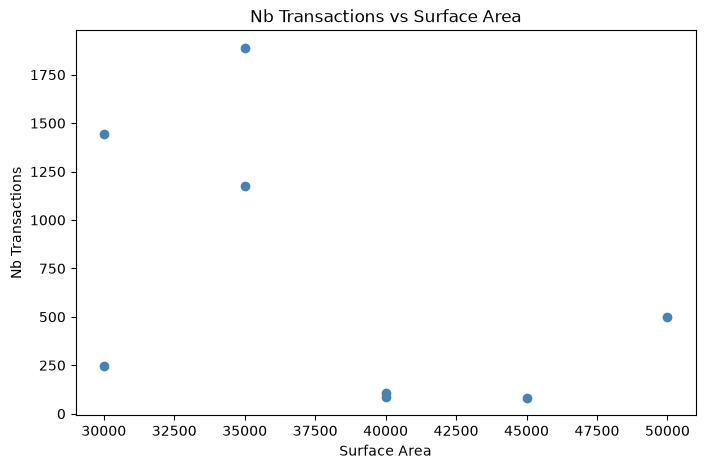

In [12]:
# Vérifier s'il y a un lien entre la surface de la région et ses ventes

transactions_df_loc = transactions_df.merge(locations_df[["Region Type","Surface Area","Location ID"]], on="Location ID", how="left")

nb_transactions = transactions_df_loc.groupby("Location ID").agg(
    Nb_Transactions=("Location ID", "count"),
    Surface_Area=("Surface Area", "first")
).reset_index()

nb_transactions["Surface_Area"] = (nb_transactions["Surface_Area"]
                                    .str.replace(",", "", regex=False)
                                    .astype(float))

plt.figure(figsize=(8, 5))
plt.scatter(nb_transactions["Surface_Area"], nb_transactions["Nb_Transactions"], color="steelblue")
plt.xlabel("Surface Area")
plt.ylabel("Nb Transactions")
plt.title("Nb Transactions vs Surface Area")
plt.show()

In [13]:
# Vérification de la taille des données d'entrainement par région et par SKU
density_check_df = transactions_df.merge(locations_df[["Location ID", "Region Type"]], on="Location ID", how="left")

display(density_check_df.groupby("Location ID").size())
display(density_check_df.groupby("Region Type").size())
display(density_check_df.groupby("SKU").size())

Location ID
1     1442
2     1667
3      500
4      106
5       88
6      247
7     1175
8     1888
9      757
10      81
dtype: int64

Region Type
Rural         2751
Semi-Urban    1675
Urban         3525
dtype: int64

SKU
Alpha    3094
Beta      884
Gamma    3973
dtype: int64

In [14]:
# Vérification de la densité granulaire

density_check_df["Year"] = pd.to_datetime(density_check_df["Date"]).dt.year
density_check_df["Month"] = pd.to_datetime(density_check_df["Date"]).dt.month

pivot = (density_check_df
         .groupby(["Region Type", "SKU", "Year", "Month"])
         .size()
         .unstack(["Year", "Month"])
         .fillna(0)
         .astype(int))

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(pivot)

Year              2021                                         2022          \
Month               2   3   4   5   6   7   8   9   10  11  12   1   2   3    
Region Type SKU                                                               
Rural       Alpha   12  17  17  28  20  22  20  25  61  48  36   23  25  21   
            Beta     4   5   4   4  11   4   9   6   6   8  11    3  12   4   
            Gamma   26  19  20  18  20  15  33  12  31  29  48   41  32  27   
Semi-Urban  Alpha    5   9  21  14  10  11  16  17  35  36  28   20  15  15   
            Beta     3   1   3   5   2   1   3   0   4   4   1    2   7   3   
            Gamma   11  13  13  21   6  22  18  13  24  22  15   12  21  14   
Urban       Alpha   17  24  19  40  28  27  33  33  56  85  60   28  35  27   
            Beta     4   9   8   7   7   9  10  12  12  12   9   10   7   7   
            Gamma   23  32  25  35  25  37  28  34  52  37  47   23  30  34   

Year                                          2023                     2024  \
Month              4   5   6   7   8   9   10   2   3   4   5   11  12   1    
Region Type SKU                                                               
Rural       Alpha  20  16  19  19  14  25  22   25  31  23  18  61  42   23   
            Beta    2   6   2   3   1  12   9    6   4   7   4   4   8    3   
            Gamma  21  33  42  18  40  30  24   33  27  28  22  31  27   23   
Semi-Urban  Alpha   9   6  12  19  17  14  15    4  14  17  10  32  32   10   
            Beta   10   0   1   3   1   2   7    2   1   6   3   4   8    4   
            Gamma  15  15  21  10  16  16  17   14  23   7  18  21  29   16   
Urban       Alpha  16  26  17  20  27  17  32   11  28  14  26  82  57   34   
            Beta    8  10  10   7  10   4  19    5   4   8  16   8  12    8   
            Gamma  22  22  34  35  31  45  61   18  24  22  27  50  65   35   

Year                                                          2025          \
Month              2   3   4   5   6   7   8   9   10  11  12   1   2   3    
Region Type SKU                                                              
Rural       Alpha  22  17  19  15  16  18  23  22  49  56  44   24  23  14   
            Beta    5   1   8   3   8   7   2   5   9   6  12    3   9   5   
            Gamma  27  25  28  17  17  23  23  25  40  36  43   18  18  24   
Semi-Urban  Alpha  13   8  20  13  16  21   6  10  33  29  36   12  14  11   
            Beta    4   6   2   1   3   1   3   6   9   2   2    0   1   1   
            Gamma  14  14  12  15   9  14   8  18  21  24  28   16  11  15   
Urban       Alpha  38  33  16  23  26  24  33  25  38  28  39   20  17  15   
            Beta    7   6   3   8   3   9   9  11   7  13  12    7   5  11   
            Gamma  27  42  35  20  26  36  23  29  50  76  49   33  37  24   

Year              2022     2023                      
Month               11  12   1   6   7   8   9   10  
Region Type SKU                                      
Rural       Alpha    0   0    0   0   0   0   0   0  
            Beta     3  14    7   6  10   3   4   9  
            Gamma   44  31   25  28  27  21  10  35  
Semi-Urban  Alpha    0   0    0   0   0   0   0   0  
            Beta     3   9    1   0   2   3   1   4  
            Gamma   20  27   16  14  10  14  12  20  
Urban       Alpha    0   0    0   0   0   0   0   0  
            Beta     6  17    0   5   6   6  10  15  
            Gamma   58  50   36  44  19  39  40  57

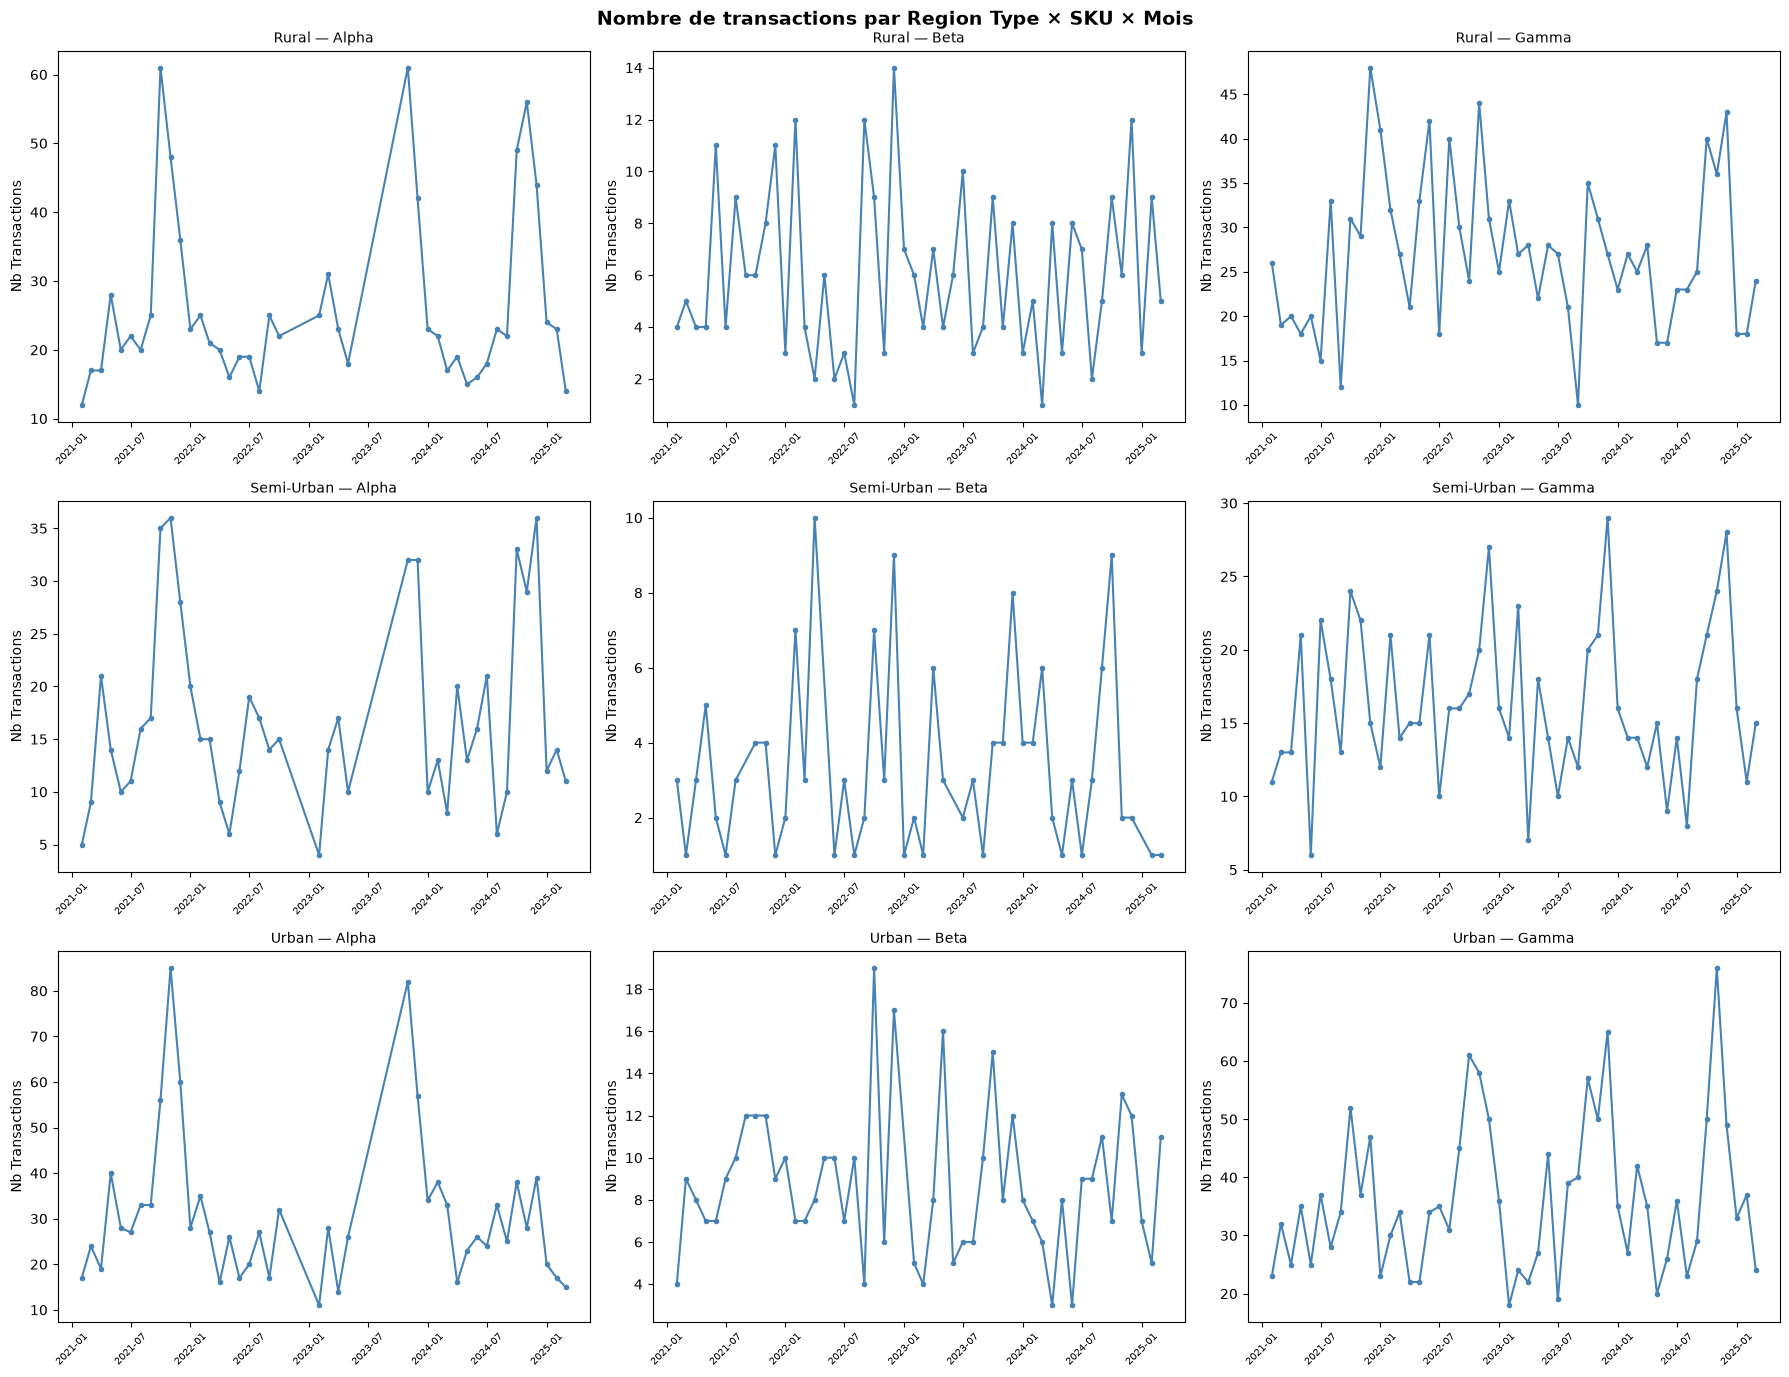

In [15]:
# Représentation visuelle des données du dataset

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle("Nombre de transactions par Region Type × SKU × Mois", fontsize=14, fontweight="bold")

for i, region in enumerate(["Rural", "Semi-Urban", "Urban"]):
    for j, sku in enumerate(["Alpha", "Beta", "Gamma"]):
        ax = axes[i, j]

        subset = density_check_df[
            (density_check_df["Region Type"] == region) &
            (density_check_df["SKU"] == sku)
        ].groupby(["Year", "Month"]).size().reset_index(name="Nb_Transactions")

        subset["Période"] = pd.to_datetime(
            subset["Year"].astype(str) + "-" + subset["Month"].astype(str).str.zfill(2)
        )

        ax.plot(subset["Période"], subset["Nb_Transactions"],
                color="steelblue", marker="o", markersize=3)
        ax.set_title(f"{region} — {sku}", fontsize=10)
        ax.set_ylabel("Nb Transactions")
        ax.tick_params(axis="x", rotation=45, labelsize=7)

plt.tight_layout()
plt.show()

# Conclusions de l'EDA

L'exploration des données a révélé plusieurs anomalies à traiter avant toute modélisation. On a identifié 79 transactions à quantité négative (-1), interprétées comme des retours, ainsi qu'une transaction isolée à quantité 132, vraisemblablement une erreur de saisie. Pour les retours, on a cherché à apparier chaque transaction négative avec sa transaction d'origine correspondante (même SKU, même location, même valeur opposée), afin de retirer les deux ensemble du dataset.

Par ailleurs, il n'y a aucune relation visible entre la surface de chaque location et sa quantité de transactions, nous allons donc retirer cette feature.4

Enfin, l'analyse de la densité par SKU indique que le découpage par Location ne permettra pas une prédiction de qualité. Cependant, les volumes sont suffisants pour entraîner un modèle à la granularité SKU × Region Type × Mois, à l'exception du SKU Beta qui présente des volumes significativement plus faibles. Pour le SKU Bêta, nous pourrions le regrouper avec le SKU Alpha, mais il me semble plus cohérent de garder les prédictions séparées, quitte à les aggréger à la fin, en fonction du besoin.

La partie 2 se concentre sur la préparation du dataset : suppression des transactions anomales, encodage des variables catégorielles, et construction des datasets nécessaires à la modélisation.

# 2. TRAVAIL SUR LE DATASET

In [16]:
# Ajouter le type de location dans transactions_df

locations_df["Location ID"] = locations_df["Location ID"].astype(int)
transactions_df_loc = transactions_df.merge(locations_df[["Region Type","Surface Area","Location ID"]], on="Location ID", how="left")

transactions_df_loc.head()

,Transaction ID,Date,Location ID,SKU,Quantity,Value ($),Region Type,Surface Area
0,9c42d970-ad54-47af-a151-8ba6955cc539,2021-02-01,8,Alpha,2,199.98,Rural,35000
1,3f8cdb5c-3cc6-4851-ab35-315e41374749,2021-02-01,1,Alpha,1,99.99,Urban,"30,000"
2,b797ce5d-484c-4227-bf8f-9128599439e1,2021-02-02,9,Gamma,1,39.99,Rural,NaN
3,af535905-a385-403d-9eeb-ce10a4749412,2021-02-02,9,Gamma,1,39.99,Rural,NaN
4,b2edee5d-a3d0-4968-a0f8-98af60f51085,2021-02-03,7,Gamma,1,39.99,Semi-Urban,35000


In [17]:
# Adapter le format des colonnes pour l'entrainement du modèle
from sklearn.preprocessing import OrdinalEncoder

transactions_df_format = transactions_df_loc.copy()

# Ordinal Encoding pour Region Type (one-hot encoding aurait pu être une option également)
region_order = [["Urban", "Semi-Urban", "Rural"]]
ordinal_enc = OrdinalEncoder(categories=region_order)
transactions_df_format["Region Type"] = ordinal_enc.fit_transform(transactions_df_format[["Region Type"]])

# Retirer la colonne Location ID car le dataset ne possède pas assez de données par catégorie pour l'entrainement
transactions_df_format = transactions_df_format.drop(columns=["Location ID"])

transactions_df_format.head()

,Transaction ID,Date,SKU,Quantity,Value ($),Region Type,Surface Area
0,9c42d970-ad54-47af-a151-8ba6955cc539,2021-02-01,Alpha,2,199.98,2.0,35000
1,3f8cdb5c-3cc6-4851-ab35-315e41374749,2021-02-01,Alpha,1,99.99,0.0,"30,000"
2,b797ce5d-484c-4227-bf8f-9128599439e1,2021-02-02,Gamma,1,39.99,2.0,NaN
3,af535905-a385-403d-9eeb-ce10a4749412,2021-02-02,Gamma,1,39.99,2.0,NaN
4,b2edee5d-a3d0-4968-a0f8-98af60f51085,2021-02-03,Gamma,1,39.99,1.0,35000


In [18]:
# Retirer les transactions à quantity = -1 et les transactions à quantity = +1 correspondantes déterminées lors de la section précédente

neg_ids  = [id for ids in comparison["neg_ids"] for id in ids]

pos_ids  = [id 
            for _, row in comparison.iterrows() 
            for id in row["pos_ids"][:int(row["neg_count"])]]

corr_ids = problematic_corresponding_transactions["Transaction ID_matched"].dropna().tolist()

ids_to_remove = list(set(neg_ids + pos_ids + corr_ids))

transactions_df_noreturns = transactions_df_format[~transactions_df_format["Transaction ID"].isin(ids_to_remove)]

# Retirer la transaction de 132 ventes (cas extrême, vente unique sans-doute)
transactions_df_noreturns = transactions_df_noreturns[transactions_df_noreturns["Quantity"] != 132]

# Retirer la colonne Transaction ID et la colonne Value ($)
transactions_df_quantity = transactions_df_noreturns.drop(columns=["Transaction ID", "Value ($)","Surface Area"])

# On valide que transactions_df_quantitya bien 7951 - 79*2 - 1 rows, soit 7792 rows
len(transactions_df_quantity)

7792

In [19]:
# Ajouter le bénéfice (Non-utilisé pour le modèle de prédiction des quantités subséquent)
products_df["Unit Cost ($)"] = (products_df["MSRP ($)"] * (100 - products_df["Margin (%)"]) / 100).round(2)

transactions_df_sales_and_benef = transactions_df_noreturns.merge(products_df[["SKU", "MSRP ($)","Unit Cost ($)"]], on="SKU", how="left")
transactions_df_sales_and_benef["Unit Price Transaction"] = transactions_df_sales_and_benef["Value ($)"] / price_check_df["Quantity"]
transactions_df_sales_and_benef["Transaction Margin ($)"] = transactions_df_sales_and_benef["Quantity"] * (transactions_df_sales_and_benef["Unit Price Transaction"] - transactions_df_sales_and_benef["Unit Cost ($)"])
transactions_df_sales_and_benef = transactions_df_sales_and_benef.drop(columns = ["Quantity","MSRP ($)","Unit Cost ($)","Unit Price Transaction","Surface Area"])

display(transactions_df_sales_and_benef.columns)

Index(['Transaction ID', 'Date', 'SKU', 'Value ($)', 'Region Type',
       'Transaction Margin ($)'],
      dtype='str')

# 3. FEATURE ENGINEERING

Le feature engineering est construit autour de trois familles de variables.

Les features temporelles (mois, trimestre, encodage cyclique sinus/cosinus) permettent au modèle de capturer la saisonnalité. L'encodage cyclique est particulièrement important pour le mois : sans lui, le modèle percevrait décembre (12) et janvier (1) comme éloignés, alors qu'ils sont consécutifs dans le cycle annuel.

Les features de lag (quantités des mois M-1, M-2, M-3) fournissent au modèle un signal direct sur les ventes récentes. Chaque lag est calculé au niveau du groupe SKU × Region Type pour éviter toute contamination entre groupes.

Les features de rolling (moyennes glissantes sur 3 et 6 mois) complètent les lags en capturant la tendance de fond, moins sensible aux pics ponctuels. Le rolling à 6 mois implique cependant que les 6 premiers mois de chaque groupe sont perdus après le dropna(), ce qui est un compromis acceptable sur un historique de 4 ans.

Le nombre de transactions par mois est également inclus comme proxy de l'activité commerciale, indépendamment des quantités vendues.

In [20]:
# Feature Engineering

from sklearn.metrics import mean_absolute_error, r2_score

# ── 1. Agréger par SKU × Region Type × Mois ─────────────────────────
df = transactions_df_quantity.copy()
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

agg_df = (df.groupby(["Year", "Month", "SKU", "Region Type"])
           .agg(
               Total_Quantity=("Quantity", "sum"),
               Nb_Transactions=("Quantity", "count"),

           )
           .reset_index()
           .sort_values(["SKU", "Region Type", "Year", "Month"]))

# ── 2. Features temporelles ──────────────────────────────────────────
agg_df["Quarter"] = ((agg_df["Month"] - 1) // 3) + 1
agg_df["MonthSin"] = np.sin(2 * np.pi * agg_df["Month"] / 12)
agg_df["MonthCos"] = np.cos(2 * np.pi * agg_df["Month"] / 12)

# ── 3. Encodage SKU et Region Type ───────────────────────────────────
agg_df["SKU_encoded"] = agg_df["SKU"].astype("category").cat.codes

# ── 4. Features lag par groupe SKU × Region Type ─────────────────────
group_keys = ["SKU", "Region Type"]

for lag in [1, 2, 3]:
    agg_df[f"Quantity_lag{lag}m"] = agg_df.groupby(group_keys)["Total_Quantity"].shift(lag)
    agg_df[f"Transactions_lag{lag}m"] = agg_df.groupby(group_keys)["Nb_Transactions"].shift(lag)

agg_df["Quantity_rolling3m"] = (agg_df.groupby(group_keys)["Total_Quantity"]
                                    .transform(lambda x: x.shift(1).rolling(3).mean()))
agg_df["Quantity_rolling6m"] = (agg_df.groupby(group_keys)["Total_Quantity"]
                                    .transform(lambda x: x.shift(1).rolling(6).mean()))


agg_df = agg_df.dropna()

features = [
    "Year", "Month", "Quarter", "MonthSin", "MonthCos",
    "SKU_encoded", "Region Type",
    "Quantity_lag1m", "Quantity_lag2m", "Quantity_lag3m",
    "Transactions_lag1m", "Transactions_lag2m", "Transactions_lag3m",
    "Quantity_rolling3m", "Quantity_rolling6m"
]

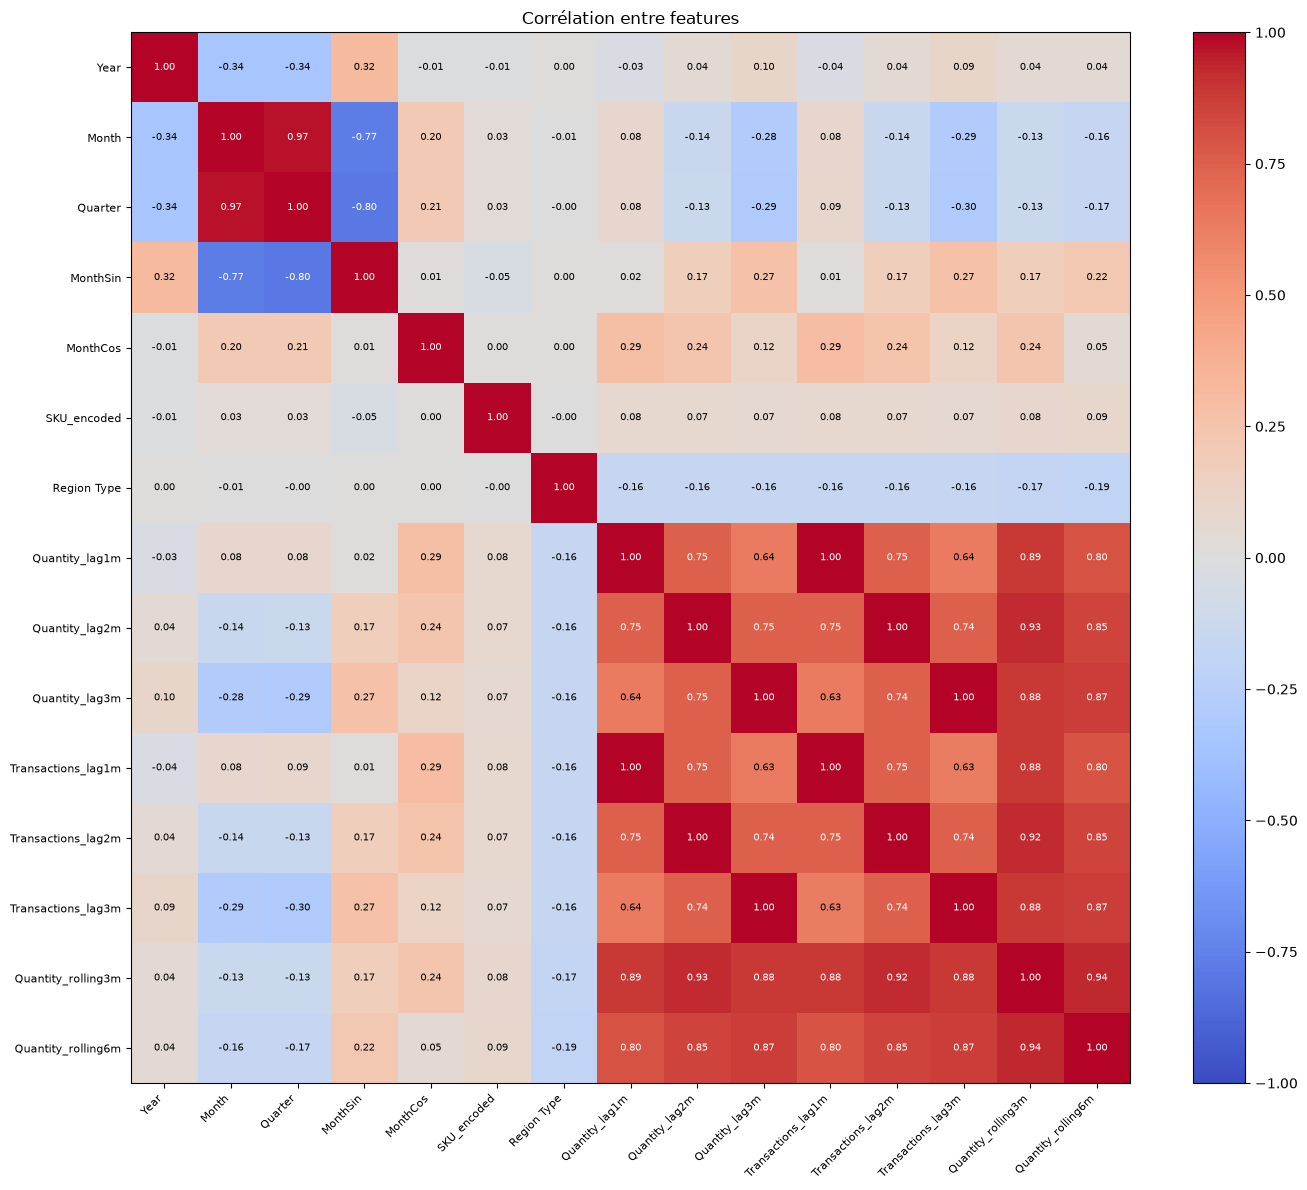

In [21]:
# Matrice de corrélation des features

corr = agg_df[features].corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr.values, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)

# Axes
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index, fontsize=8)

# Valeurs dans les cellules
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        val = corr.values[i, j]
        color = "white" if abs(val) > 0.7 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7, color=color)

plt.colorbar(im, ax=ax)
ax.set_title("Corrélation entre features")
plt.tight_layout()
plt.show()

# 4. ENTRAINEMENT D'UN MODELE POUR PREDIRE 2024

In [22]:
# Préparation des datasets d'entrainement et de test pour prédire 2024

X = agg_df[features]
y = agg_df["Total_Quantity"]

# Split temporel
train_mask = agg_df["Year"] <= 2023
test_mask  = (agg_df["Year"] == 2024)

X_train = agg_df.loc[train_mask, features]
X_test  = agg_df.loc[test_mask, features]

y_train_ventes = agg_df.loc[train_mask, "Total_Quantity"]
y_test_ventes  = agg_df.loc[test_mask, "Total_Quantity"]


In [23]:
# Création et évaluations des modèles pour prédire 2024

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(y_true) * 100

models = {
    "GradientBoosting": Pipeline([
        ("model", GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42))
    ]),
    "RandomForest": Pipeline([
        ("model", RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42))
    ]),
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])
}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train_ventes)
    y_pred_cv = pipeline.predict(X_test)
    print(f"=== {name} ===")
    print(f"MAE : {mean_absolute_error(y_test_ventes, y_pred_cv):.2f}")
    print(f"WAPE : {wape(y_test_ventes.values, y_pred_cv):.1f}%")
    print(f"R²  : {r2_score(y_test_ventes, y_pred_cv):.3f}")
    print()

# Garder le meilleur
model_quantity = models["RandomForest"]
y_pred = model_quantity.predict(X_test)

=== GradientBoosting ===
MAE : 4.93
WAPE : 25.3%
R²  : 0.733

=== RandomForest ===
MAE : 4.62
WAPE : 23.7%
R²  : 0.782

=== Linear Regression ===
MAE : 5.49
WAPE : 28.2%
R²  : 0.707



Le meilleur modèle est donc RandomForest, sur lequel nous allons réaliser un Hyperparameter Tuning pour améliorer ses performances

In [24]:
# Hyperparameter tunning pour le modèle RandomForest (exécution en ~2 min)
from sklearn.model_selection import ParameterGrid

param_grid = {
    "model__n_estimators":     [100, 200, 500],
    "model__max_depth":        [3, 4, 5, None],
    "model__min_samples_leaf": [1, 5, 10],
    "model__max_features":     ["sqrt", "log2", 0.8]
}

best_wape   = np.inf
best_params = None
best_model  = None

for params in ParameterGrid(param_grid):
    rf_pipeline = Pipeline([
        ("model", RandomForestRegressor(random_state=42))
    ])
    rf_pipeline.set_params(**params)
    rf_pipeline.fit(X_train, y_train_ventes)
    score = wape(y_test_ventes.values, rf_pipeline.predict(X_test))
    if score < best_wape:
        best_wape   = score
        best_params = params
        best_model  = rf_pipeline

print(f"Meilleurs paramètres : {best_params}")
print(f"Meilleur WAPE test   : {best_wape:.1f}%")

model_quantity = best_model
y_pred = model_quantity.predict(X_test)
print(f"MAE  : {mean_absolute_error(y_test_ventes, y_pred):.2f}")
print(f"WAPE : {wape(y_test_ventes.values, y_pred):.1f}%")
print(f"R²   : {r2_score(y_test_ventes, y_pred):.3f}")

Meilleurs paramètres : {'model__max_depth': 5, 'model__max_features': 0.8, 'model__min_samples_leaf': 5, 'model__n_estimators': 500}
Meilleur WAPE test   : 23.3%
MAE  : 4.55
WAPE : 23.3%
R²   : 0.789


In [25]:
# Prédiction naïve : moyenne du même mois les années précédentes
naive_preds = []

for _, row in agg_df.loc[test_mask].iterrows():
    same_month_history = agg_df[
        (agg_df["SKU"]         == row["SKU"]) &
        (agg_df["Region Type"] == row["Region Type"]) &
        (agg_df["Month"]       == row["Month"]) &
        (agg_df["Year"]        < row["Year"])
    ]["Total_Quantity"].mean()
    naive_preds.append(same_month_history)

A titre indicatif, nous allons étudier les résultats du modèle, et les comparer à un modèle "naïf" qui prédit la moyenne du même mois des années précédentes pour l'année 2024.

In [26]:
# Résultats détaillés
results = agg_df.loc[test_mask, ["Year", "Month", "SKU", "Region Type"]].copy()
results["Réel"]           = y_test_ventes.values
results["Prédit"]         = y_pred
results["Naïf"]           = naive_preds
results["Écart ($)"]      = results["Prédit"] - results["Réel"]
results["Écart_naïf ($)"] = results["Naïf"] - results["Réel"]

print("\n=== Résultats par SKU × Region Type ===")
display(results.sort_values(["SKU", "Region Type", "Year", "Month"]))

print("\n=== Comparaison Modèle vs Naïf ===")
comparison = pd.DataFrame({
    "Modèle MAE":  [results["Écart ($)"].abs().mean()],
    "Naïf MAE":    [results["Écart_naïf ($)"].abs().mean()],
    "Modèle WAPE": [wape(results["Réel"].values, results["Prédit"].values)],
    "Naïf WAPE":   [wape(results["Réel"].values, results["Naïf"].values)],
    "Modèle R²":   [r2_score(results["Réel"], results["Prédit"])],
    "Naïf R²":     [r2_score(results["Réel"], results["Naïf"])]
}).round(2)
display(comparison)

print("\n=== Erreur moyenne par SKU ===")
display(results.groupby("SKU").apply(lambda g: pd.Series({
    "MAE_modèle":   g["Écart ($)"].abs().mean(),
    "MAE_naïf":     g["Écart_naïf ($)"].abs().mean(),
    "WAPE_modèle":  wape(g["Réel"].values, g["Prédit"].values),
    "WAPE_naïf":    wape(g["Réel"].values, g["Naïf"].values),
    "Biais_modèle": g["Écart ($)"].mean(),
    "Biais_naïf":   g["Écart_naïf ($)"].mean()
})).round(2))

print("\n=== Erreur moyenne par Region Type ===")
display(results.groupby("Region Type").apply(lambda g: pd.Series({
    "MAE_modèle":  g["Écart ($)"].abs().mean(),
    "MAE_naïf":    g["Écart_naïf ($)"].abs().mean(),
    "WAPE_modèle": wape(g["Réel"].values, g["Prédit"].values),
    "WAPE_naïf":   wape(g["Réel"].values, g["Naïf"].values),
})).round(2))

print("\n=== Erreur moyenne par Mois ===")
display(results.groupby("Month").apply(lambda g: pd.Series({
    "MAE_modèle":  g["Écart ($)"].abs().mean(),
    "MAE_naïf":    g["Écart_naïf ($)"].abs().mean(),
    "WAPE_modèle": wape(g["Réel"].values, g["Prédit"].values),
    "WAPE_naïf":   wape(g["Réel"].values, g["Naïf"].values),
})).round(2))

print("\n=== Importance des features ===")
importance_df = pd.DataFrame({
    "Feature":    features,
    "Importance": model_quantity.named_steps["model"].feature_importances_
}).sort_values("Importance", ascending=False)
display(importance_df)


=== Résultats par SKU × Region Type ===


,Year,Month,SKU,Region Type,Réel,Prédit,Naïf,Écart ($),Écart_naïf ($)
287,2024,1,Alpha,0.0,37,31.020696,24.000000,-5.979304,-13.000000
296,2024,2,Alpha,0.0,41,26.643671,23.000000,-14.356329,-18.000000
305,2024,3,Alpha,0.0,31,26.584188,27.500000,-4.415812,-3.500000
314,2024,4,Alpha,0.0,16,25.835951,16.500000,9.835951,0.500000
323,2024,5,Alpha,0.0,24,24.867988,27.000000,0.867988,3.000000
...,...,...,...,...,...,...,...,...,...
357,2024,8,Gamma,2.0,24,19.955767,32.666667,-4.044233,8.666667
366,2024,9,Gamma,2.0,23,21.924200,17.666667,-1.075800,-5.333333
375,2024,10,Gamma,2.0,41,38.814832,30.000000,-2.185168,-11.000000
384,2024,11,Gamma,2.0,38,40.541688,34.333333,2.541688,-3.666667



=== Comparaison Modèle vs Naïf ===


,Modèle MAE,Naïf MAE,Modèle WAPE,Naïf WAPE,Modèle R²,Naïf R²
0,4.55,5.57,23.34,28.57,0.79,0.64



=== Erreur moyenne par SKU ===


,MAE_modèle,MAE_naïf,WAPE_modèle,WAPE_naïf,Biais_modèle,Biais_naïf
SKU,,,,,,
Alpha,6.92,6.94,27.32,27.41,0.64,0.83
Beta,2.28,2.71,38.94,46.26,0.19,0.46
Gamma,4.39,6.99,16.30,25.93,-0.46,0.13



=== Erreur moyenne par Region Type ===


,MAE_modèle,MAE_naïf,WAPE_modèle,WAPE_naïf
Region Type,,,,
0.0,5.75,8.11,22.73,32.05
1.0,3.95,4.28,30.44,32.97
2.0,3.94,4.30,19.63,21.42



=== Erreur moyenne par Mois ===


,MAE_modèle,MAE_naïf,WAPE_modèle,WAPE_naïf
Month,,,,
1,3.16,5.33,18.38,30.97
2,4.20,4.17,23.46,23.29
3,5.68,5.94,33.64,35.20
4,5.31,5.00,32.09,30.20
5,3.14,3.89,24.19,29.91
6,3.26,6.72,23.48,48.40
7,2.60,3.12,13.48,16.23
8,4.89,5.52,33.37,37.63
9,3.24,4.59,19.32,27.37



=== Importance des features ===


,Feature,Importance
13,Quantity_rolling3m,0.448948
14,Quantity_rolling6m,0.183562
1,Month,0.092377
2,Quarter,0.066620
8,Quantity_lag2m,0.044099
10,Transactions_lag1m,0.032976
7,Quantity_lag1m,0.028879
6,Region Type,0.027782
11,Transactions_lag2m,0.023008
12,Transactions_lag3m,0.013636


Notre modèle prédit mieux que la prédiction naïve !

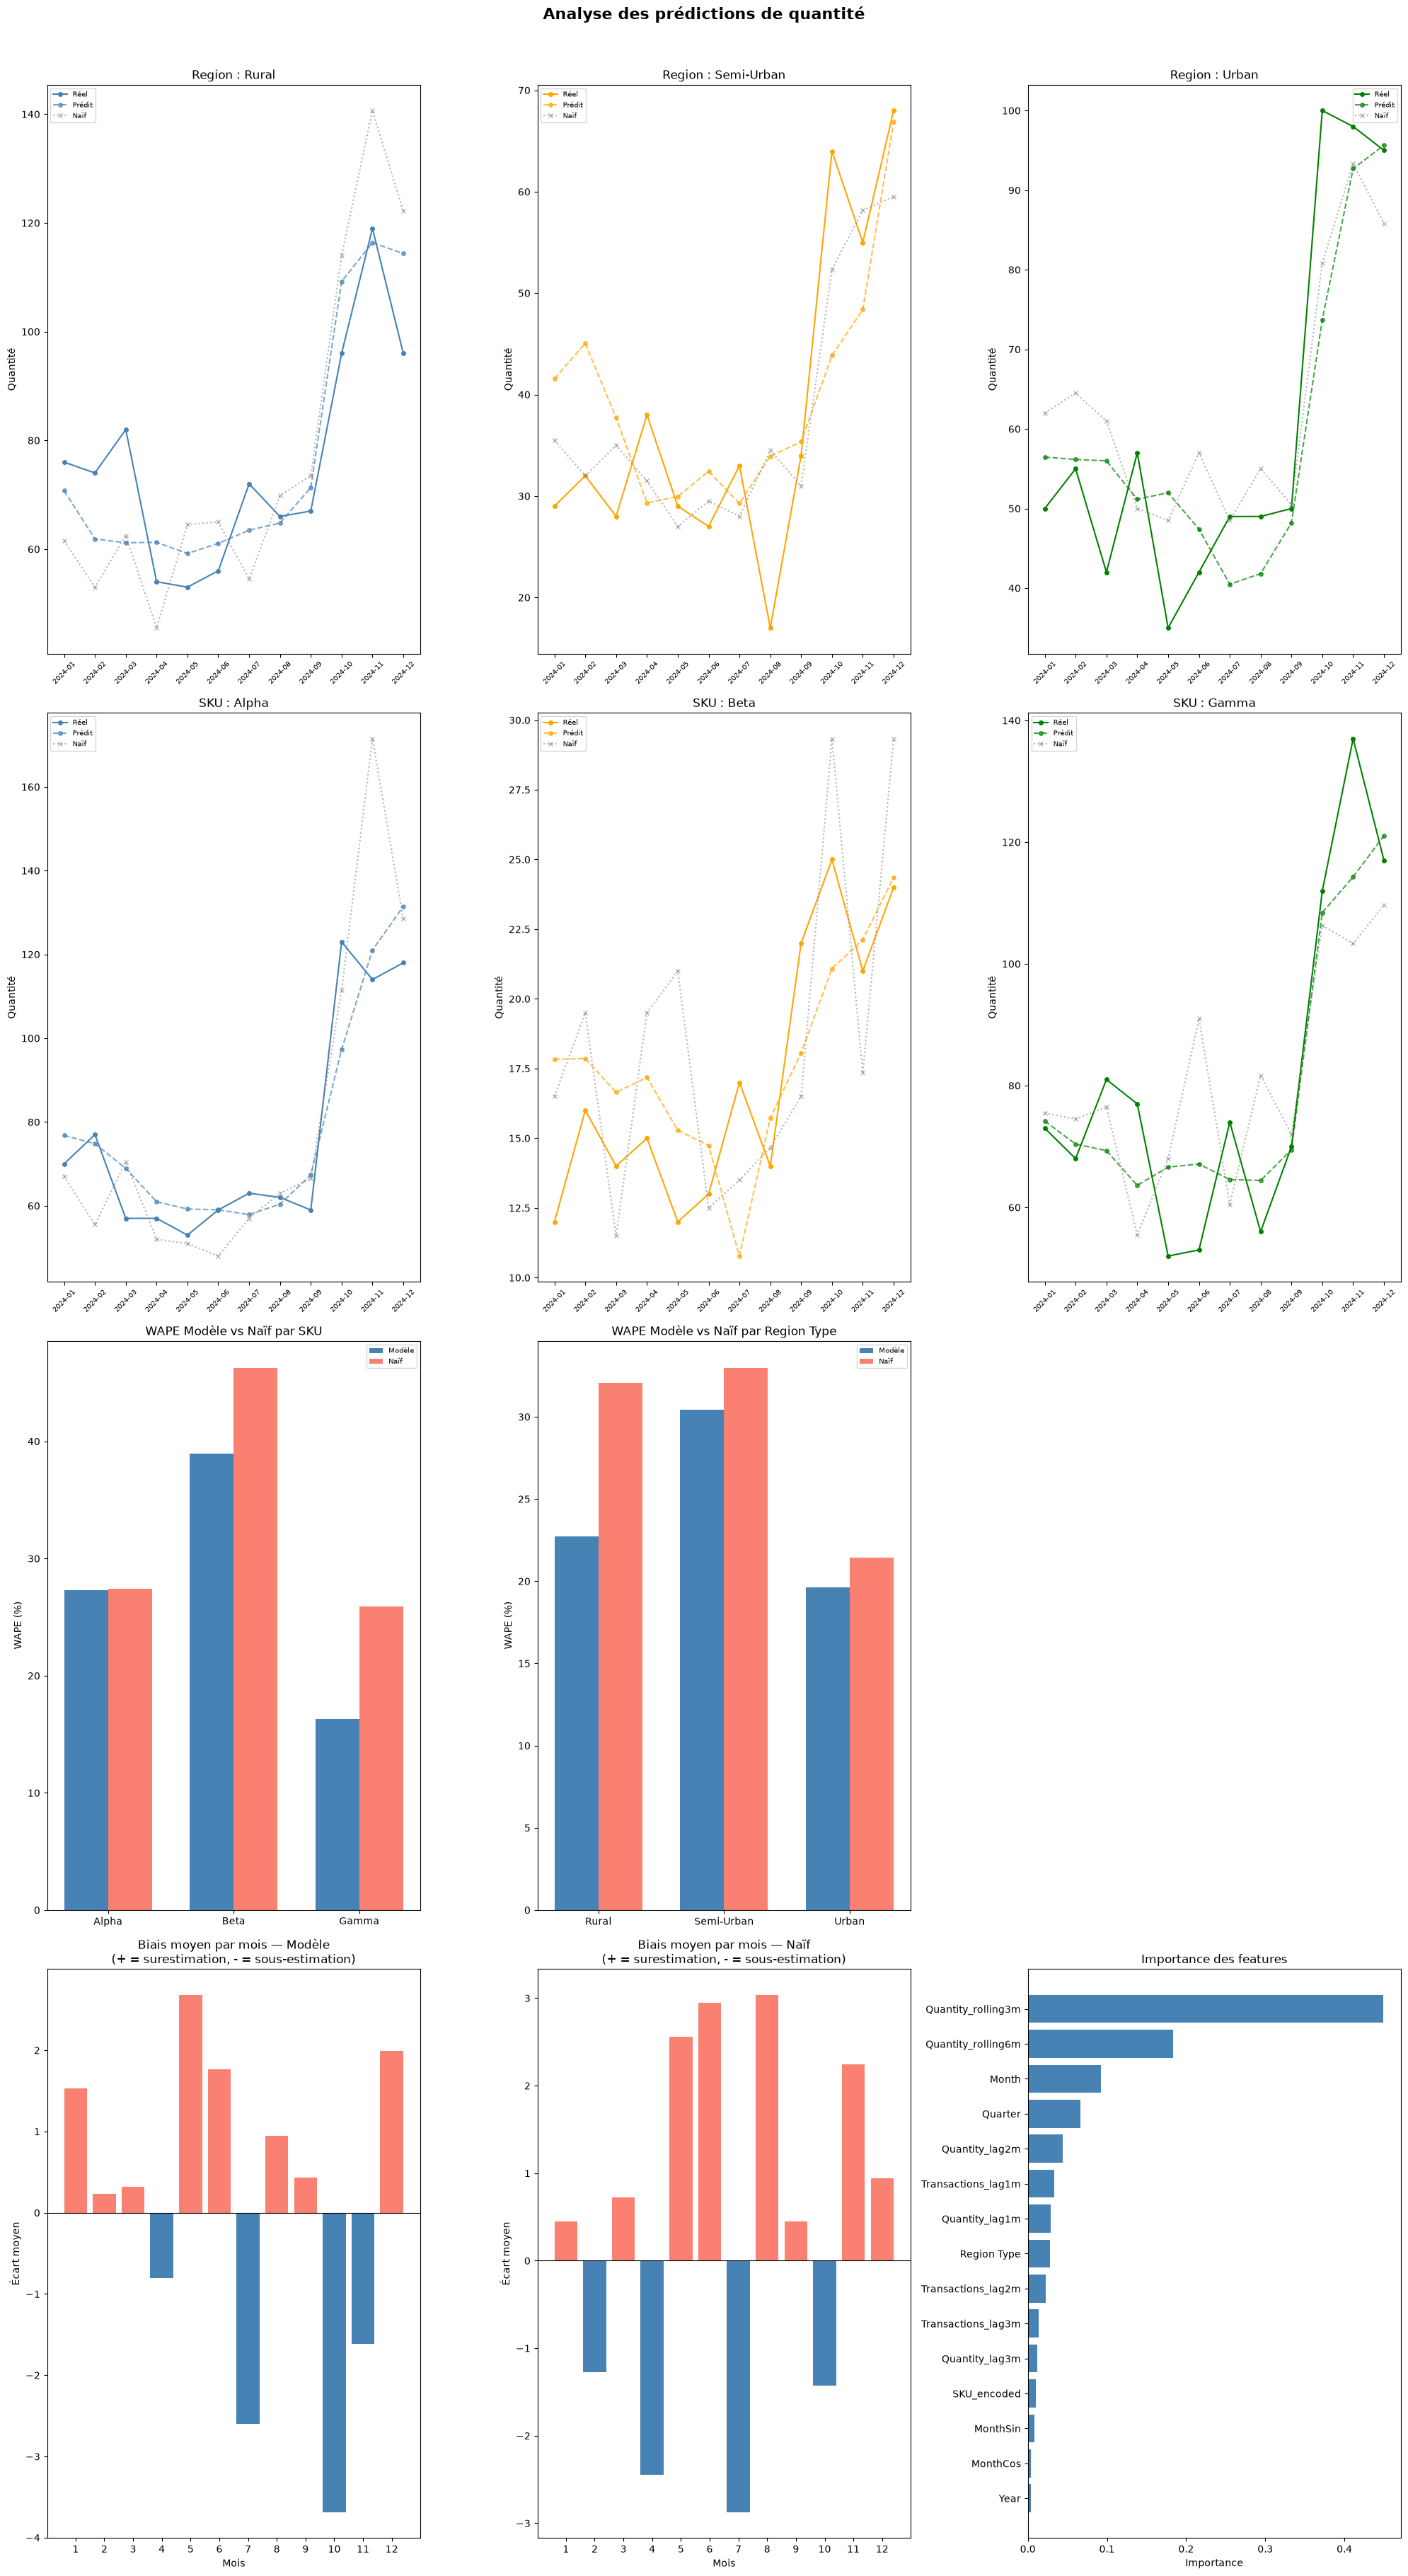

In [ ]:
# Résultats visuels
import matplotlib.ticker as mticker

fig, axes = plt.subplots(4, 3, figsize=(20, 36))
fig.suptitle("Analyse des prédictions de quantité", fontsize=16, fontweight="bold", y=1.01)

region_map    = {0: "Rural", 1: "Semi-Urban", 2: "Urban"}
colors_region = {"Rural": "steelblue", "Semi-Urban": "orange", "Urban": "green"}
colors_sku    = {"Alpha": "steelblue", "Beta": "orange", "Gamma": "green"}
width = 0.35

results["Region Label"] = results["Region Type"].map(region_map)

monthly_region = results.groupby(["Year", "Month", "Region Type"])[["Réel", "Prédit", "Naïf"]].sum().reset_index()
monthly_region["Période"]      = monthly_region["Year"].astype(str) + "-" + monthly_region["Month"].astype(str).str.zfill(2)
monthly_region["Region Label"] = monthly_region["Region Type"].map(region_map)

monthly_sku = results.groupby(["Year", "Month", "SKU"])[["Réel", "Prédit", "Naïf"]].sum().reset_index()
monthly_sku["Période"] = monthly_sku["Year"].astype(str) + "-" + monthly_sku["Month"].astype(str).str.zfill(2)

# ── Ligne 1 : Réel vs Prédit vs Naïf par Region Type ─────────────────
for j, region in enumerate(["Rural", "Semi-Urban", "Urban"]):
    ax = axes[0, j]
    subset = monthly_region[monthly_region["Region Label"] == region]
    ax.plot(subset["Période"], subset["Réel"],   label="Réel",   color=colors_region[region], marker="o", markersize=4)
    ax.plot(subset["Période"], subset["Prédit"], label="Prédit", color=colors_region[region], marker="o", markersize=4, linestyle="--", alpha=0.7)
    ax.plot(subset["Période"], subset["Naïf"],   label="Naïf",   color="gray",                marker="x", markersize=4, linestyle=":",  alpha=0.6)
    ax.set_title(f"Region : {region}")
    ax.set_ylabel("Quantité")
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.legend(fontsize=7)

# ── Ligne 2 : Réel vs Prédit vs Naïf par SKU ─────────────────────────
for j, sku in enumerate(["Alpha", "Beta", "Gamma"]):
    ax = axes[1, j]
    subset = monthly_sku[monthly_sku["SKU"] == sku]
    ax.plot(subset["Période"], subset["Réel"],   label="Réel",   color=colors_sku[sku], marker="o", markersize=4)
    ax.plot(subset["Période"], subset["Prédit"], label="Prédit", color=colors_sku[sku], marker="o", markersize=4, linestyle="--", alpha=0.7)
    ax.plot(subset["Période"], subset["Naïf"],   label="Naïf",   color="gray",          marker="x", markersize=4, linestyle=":",  alpha=0.6)
    ax.set_title(f"SKU : {sku}")
    ax.set_ylabel("Quantité")
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.legend(fontsize=7)

# ── Ligne 3 : WAPE Modèle vs Naïf par SKU ────────────────────────────
ax = axes[2, 0]
sku_wape = results.groupby("SKU").apply(lambda g: pd.Series({
    "WAPE_modèle": wape(g["Réel"].values, g["Prédit"].values),
    "WAPE_naïf":   wape(g["Réel"].values, g["Naïf"].values)
}))
x = np.arange(len(sku_wape))
ax.bar(x - width/2, sku_wape["WAPE_modèle"], width, label="Modèle", color="steelblue")
ax.bar(x + width/2, sku_wape["WAPE_naïf"],   width, label="Naïf",   color="salmon")
ax.set_xticks(x)
ax.set_xticklabels(sku_wape.index)
ax.set_title("WAPE Modèle vs Naïf par SKU")
ax.set_ylabel("WAPE (%)")
ax.legend(fontsize=7)

# ── Ligne 3 : WAPE Modèle vs Naïf par Region Type ────────────────────
ax = axes[2, 1]
region_wape = results.groupby("Region Label").apply(lambda g: pd.Series({
    "WAPE_modèle": wape(g["Réel"].values, g["Prédit"].values),
    "WAPE_naïf":   wape(g["Réel"].values, g["Naïf"].values)
}))
x = np.arange(len(region_wape))
ax.bar(x - width/2, region_wape["WAPE_modèle"], width, label="Modèle", color="steelblue")
ax.bar(x + width/2, region_wape["WAPE_naïf"],   width, label="Naïf",   color="salmon")
ax.set_xticks(x)
ax.set_xticklabels(region_wape.index)
ax.set_title("WAPE Modèle vs Naïf par Region Type")
ax.set_ylabel("WAPE (%)")
ax.legend(fontsize=7)

axes[2, 2].axis("off")

# ── Ligne 4 : Biais par mois — Modèle ────────────────────────────────
ax = axes[3, 0]
monthly_bias = results.groupby("Month")["Écart ($)"].mean()
colors = ["salmon" if v > 0 else "steelblue" for v in monthly_bias]
ax.bar(monthly_bias.index, monthly_bias.values, color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Biais moyen par mois — Modèle\n(+ = surestimation, - = sous-estimation)")
ax.set_xlabel("Mois")
ax.set_ylabel("Écart moyen")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

# ── Ligne 4 : Biais par mois — Naïf ──────────────────────────────────
ax = axes[3, 1]
monthly_bias_naif = results.groupby("Month")["Écart_naïf ($)"].mean()
colors = ["salmon" if v > 0 else "steelblue" for v in monthly_bias_naif]
ax.bar(monthly_bias_naif.index, monthly_bias_naif.values, color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Biais moyen par mois — Naïf\n(+ = surestimation, - = sous-estimation)")
ax.set_xlabel("Mois")
ax.set_ylabel("Écart moyen")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

# ── Ligne 4 : Importance des features ────────────────────────────────
ax = axes[3, 2]
importance_df = pd.DataFrame({
    "Feature":    features,
    "Importance": model_quantity.named_steps["model"].feature_importances_
}).sort_values("Importance")
ax.barh(importance_df["Feature"], importance_df["Importance"], color="steelblue")
ax.set_title("Importance des features")
ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

# 5. ENTRAINEMENT D'UN MODELE POUR PREDIRE 2025

Pour la prédiction de 2025, on réutilise le RandomForest avec les hyperparamètres optimisés en partie 4, qui s'est avéré le plus performant sur 2024 (meilleur WAPE, meilleure MAE). Le modèle est ré-entraîné sur l'ensemble des données disponibles — 2021 à mars 2025 inclus — afin de tirer parti de l'historique le plus complet possible avant de prédire.

Pour les mois d'avril à décembre 2025, on adopte une approche récursive : les prédictions de chaque mois sont réinjectées comme lags pour prédire le mois suivant. C'est la seule approche réaliste en production, puisqu'on ne dispose évidemment pas des vraies ventes futures. Cette méthode implique une accumulation potentielle des erreurs sur l'horizon de prédiction — une erreur en avril se répercute dans les lags de mai, juin, etc. C'est pourquoi les prédictions des derniers mois de l'année sont à interpréter avec davantage de prudence que celles des premiers mois.

In [ ]:
# Préparation des datasets pour prédire 2025

# Train : tout jusqu'à mars 2025 inclus (vraie data disponible)
train_mask_final = (agg_df["Year"] <= 2024) | (
    (agg_df["Year"] == 2025) & (agg_df["Month"] <= 3)
)

# Test : avril 2025 et après
test_mask_final = (agg_df["Year"] == 2025) & (agg_df["Month"] > 3)

X_train_2025 = agg_df.loc[train_mask_final, features]
y_train_2025 = agg_df.loc[train_mask_final, "Total_Quantity"]

In [29]:
# Entraînement du modèle final
model_2025 = Pipeline([
    ("model", RandomForestRegressor(
        max_depth=5,
        max_features=0.8,
        min_samples_leaf=5,
        n_estimators=500,
        random_state=42
    ))
])

model_2025.fit(X_train_2025, y_train_2025)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Year','Month','Quarter',...,'Transactions_lag3m','Quantity_rolling3m', 'Quantity_rolling6m']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.

In [30]:
# Prédiction récursive pour avril → décembre 2025
extended_df_2025 = agg_df.copy()
extended_df_2025["Total_Quantity"] = extended_df_2025["Total_Quantity"].astype(float)

recursive_preds_2025 = []
months_to_predict_2025 = (
    pd.DataFrame({"Year": 2025, "Month": range(4, 13)})
    .sort_values(["Year", "Month"])
)

for _, period in months_to_predict_2025.iterrows():
    year, month = period["Year"], period["Month"]

    current_mask = (
        (extended_df_2025["Year"] == year) &
        (extended_df_2025["Month"] == month)
    )

    # Si le mois n'existe pas encore dans le df, on l'ajoute
    if current_mask.sum() == 0:
        new_rows = agg_df[["SKU", "SKU_encoded", "Region Type"]].drop_duplicates().copy()
        new_rows["Year"]           = year
        new_rows["Month"]          = month
        new_rows["Quarter"]        = ((month - 1) // 3) + 1
        new_rows["MonthSin"]       = np.sin(2 * np.pi * month / 12)
        new_rows["MonthCos"]       = np.cos(2 * np.pi * month / 12)
        new_rows["Total_Quantity"] = 0.0
        new_rows["Nb_Transactions"] = 0
        extended_df_2025 = pd.concat([extended_df_2025, new_rows], ignore_index=True)
        extended_df_2025 = extended_df_2025.sort_values(["SKU", "Region Type", "Year", "Month"]).reset_index(drop=True)
        current_mask = (
            (extended_df_2025["Year"] == year) &
            (extended_df_2025["Month"] == month)
        )

    # Recalculer les lags
    for lag in [1, 2, 3]:
        extended_df_2025.loc[current_mask, f"Quantity_lag{lag}m"] = (
            extended_df_2025.groupby(["SKU", "Region Type"])["Total_Quantity"].shift(lag)
            .loc[current_mask]
        )
        extended_df_2025.loc[current_mask, f"Transactions_lag{lag}m"] = (
            extended_df_2025.groupby(["SKU", "Region Type"])["Nb_Transactions"].shift(lag)
            .loc[current_mask]
        )

    extended_df_2025.loc[current_mask, "Quantity_rolling3m"] = (
        extended_df_2025.groupby(["SKU", "Region Type"])["Total_Quantity"]
        .transform(lambda x: x.shift(1).rolling(3).mean())
        .loc[current_mask]
    )
    extended_df_2025.loc[current_mask, "Quantity_rolling6m"] = (
        extended_df_2025.groupby(["SKU", "Region Type"])["Total_Quantity"]
        .transform(lambda x: x.shift(1).rolling(6).mean())
        .loc[current_mask]
    )

    # Prédire
    X_current = extended_df_2025.loc[current_mask, features]
    preds = model_2025.predict(X_current)
    recursive_preds_2025.extend(zip(
        extended_df_2025.loc[current_mask, "SKU"],
        extended_df_2025.loc[current_mask, "Region Type"],
        [year] * len(preds),
        [month] * len(preds),
        preds
    ))

    # Mettre à jour pour les lags suivants
    extended_df_2025.loc[current_mask, "Total_Quantity"] = preds

# Résultats
results_2025 = pd.DataFrame(recursive_preds_2025, columns=["SKU", "Region Type", "Year", "Month", "Prédit"])
results_2025["Month_label"] = results_2025["Month"].apply(lambda m: pd.Timestamp(2025, m, 1).strftime("%b"))

print("Prédictions Avril → Décembre 2025")
display(results_2025.sort_values(["SKU", "Region Type", "Month"]))

Prédictions Avril → Décembre 2025


,SKU,Region Type,Year,Month,Prédit,Month_label
0,Alpha,0.0,2025,4,19.556899,Apr
9,Alpha,0.0,2025,5,16.943215,May
18,Alpha,0.0,2025,6,17.299047,Jun
27,Alpha,0.0,2025,7,17.525594,Jul
36,Alpha,0.0,2025,8,17.142417,Aug
...,...,...,...,...,...,...
44,Gamma,2.0,2025,8,20.807793,Aug
53,Gamma,2.0,2025,9,20.554907,Sep
62,Gamma,2.0,2025,10,29.668967,Oct
71,Gamma,2.0,2025,11,36.880749,Nov


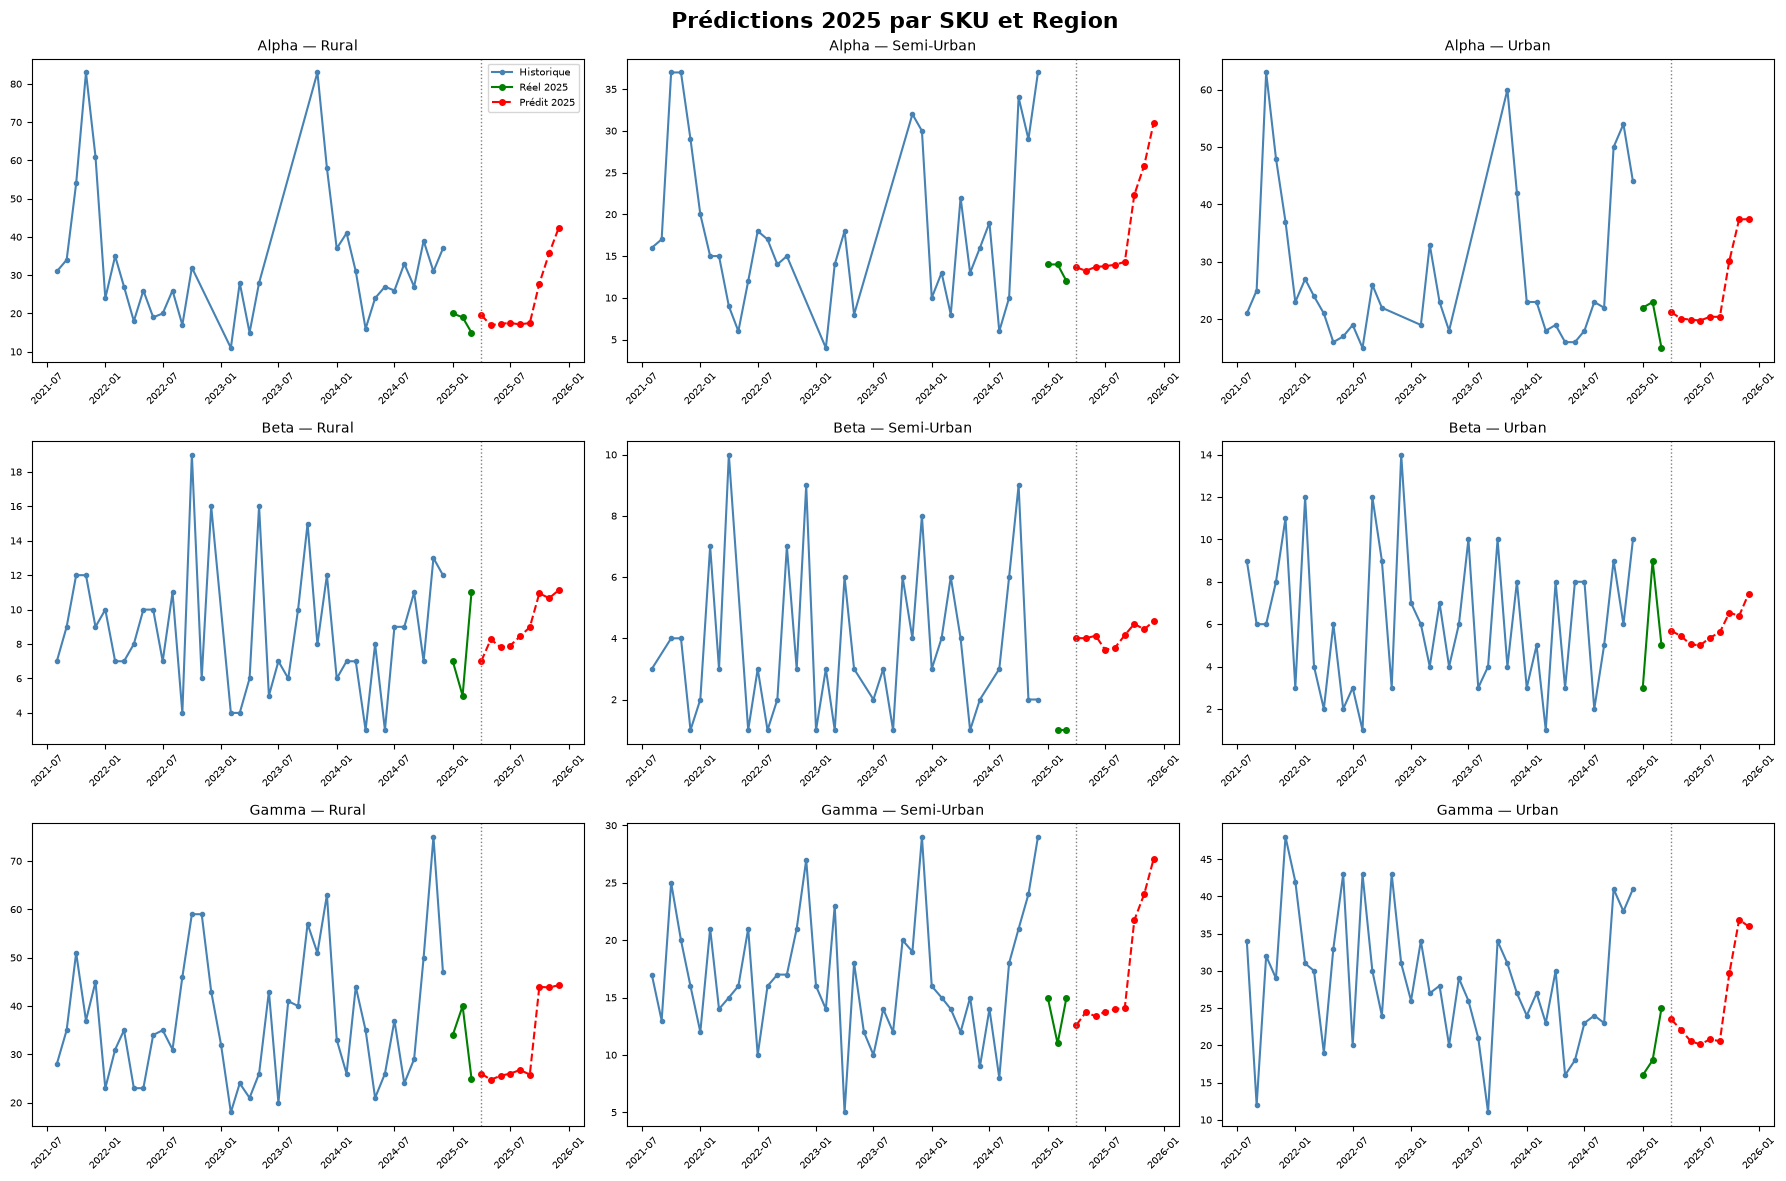

In [31]:
# Représentation visuelle des prédictions

region_map = {0: "Rural", 1: "Semi-Urban", 2: "Urban"}
results_2025["Region Label"] = results_2025["Region Type"].map(region_map)

# Historique réel pour contexte
historical = agg_df.copy()
historical["Region Label"] = historical["Region Type"].map(region_map)
historical["Période"] = pd.to_datetime(
    historical["Year"].astype(str) + "-" + historical["Month"].astype(str).str.zfill(2)
)
results_2025["Période"] = pd.to_datetime(
    results_2025["Year"].astype(str) + "-" + results_2025["Month"].astype(str).str.zfill(2)
)

skus    = ["Alpha", "Beta", "Gamma"]
regions = ["Rural", "Semi-Urban", "Urban"]

fig, axes = plt.subplots(len(skus), len(regions), figsize=(18, 12), sharey=False)
fig.suptitle("Prédictions 2025 par SKU et Region", fontsize=16, fontweight="bold")

for i, sku in enumerate(skus):
    for j, region in enumerate(regions):
        ax = axes[i, j]

        hist = historical[
            (historical["SKU"] == sku) &
            (historical["Region Label"] == region)
        ].sort_values("Période")

        pred = results_2025[
            (results_2025["SKU"] == sku) &
            (results_2025["Region Label"] == region)
        ].sort_values("Période")

        real_2025  = hist[hist["Période"] >= "2025-01-01"]
        hist_before = hist[hist["Période"] < "2025-01-01"]

        ax.plot(hist_before["Période"], hist_before["Total_Quantity"],
                color="steelblue", marker="o", markersize=3, label="Historique")
        ax.plot(real_2025["Période"], real_2025["Total_Quantity"],
                color="green", marker="o", markersize=4, label="Réel 2025")
        ax.plot(pred["Période"], pred["Prédit"],
                color="red", marker="o", markersize=4, linestyle="--", label="Prédit 2025")

        ax.axvline(pd.Timestamp("2025-03-31"), color="gray", linestyle=":", linewidth=1)
        ax.set_title(f"{sku} — {region}", fontsize=10)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=45, labelsize=7)
        ax.tick_params(axis="y", labelsize=7)

        if i == 0 and j == 0:
            ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

# Conclusion

Le modèle produit des prévisions significativement meilleures que la baseline naïve sur l'ensemble des SKU et régions.

Beta reste le segment le plus difficile à prédire en raison de ses faibles volumes.

Les prédictions 2025 constituent une base exploitable pour la planification des stocks, avec une fiabilité décroissante à mesure que l'horizon s'éloigne. Pour maintenir la précision sans réentraîner le modèle, il suffit d'alimenter le dataset avec les ventes réelles à chaque fin de mois et de relancer l'inférence — les lags se recalculent automatiquement sur des valeurs réelles plutôt que prédites.